---
---
# Universidad Federico Santa María - 2026

<img src="https://fdiaz1968.github.io/Finance-MBA/images/logo_utfsm.png" alt="Universidad Técnica Federico Santa María - Departamento de Ingeniería Comercial" style="width: 480px !important; max-width: 100% !important; height: auto !important;"/>

## FINANZAS

### Profesor Fernando Díaz H.
---

# 📐 Estimación de Betas: El Modelo de Mercado

El **beta** ($\beta$) de una acción mide cuánto se mueve, en promedio, su retorno cuando se mueve el mercado. Es la medida de **riesgo sistemático** que utiliza el CAPM y, por lo tanto, un insumo central para calcular el costo del capital propio de una empresa.

En la práctica, el beta no se observa: se **estima**. La forma estándar de hacerlo es el **modelo de mercado**, una regresión lineal simple entre el retorno de la acción y el retorno del mercado:

$$r_{i,t}=\alpha_{i}+\beta_{i}\,r_{M,t}+\varepsilon_{i,t}$$

donde:

* $r_{i,t}$ es el retorno logarítmico mensual de la acción $i$ en el mes $t$;
* $r_{M,t}$ es el retorno logarítmico mensual del mercado, aproximado por el índice **S&P IPSA**;
* $\alpha_{i}$ es el intercepto de la regresión;
* $\beta_{i}$ es la pendiente, es decir, el **beta** de la acción;
* $\varepsilon_{i,t}$ es el residuo: la parte del retorno que **no** se explica por el mercado.

En este notebook:

1. Descargaremos precios históricos de tres empresas del retail chileno —Falabella, Cencosud y Ripley— y del S&P IPSA.
2. Calcularemos sus retornos logarítmicos **mensuales**.
3. Visualizaremos la relación entre cada acción y el mercado.
4. Estimaremos el modelo de mercado para cada acción y construiremos una tabla resumen de betas, con sus errores estándar e intervalos de confianza.
5. Descompondremos el riesgo de cada acción en **sistemático** y **específico**.
6. Usaremos los betas estimados para calcular retornos esperados con el **CAPM** y graficar la Línea de Mercado de Valores (SML).
7. Repetiremos la estimación con retornos **en exceso** de la tasa libre de riesgo, para obtener el **alfa de Jensen**.

> 💡 **Idea central:** el beta es la pendiente de la regresión, pero también puede escribirse como
>
> $$\beta_{i}=\frac{\operatorname{Cov}\left(r_{i},r_{M}\right)}{\operatorname{Var}\left(r_{M}\right)}$$
>
> Es decir, mide cuánto **co-varía** la acción con el mercado, en relación con la variabilidad propia del mercado. Además, el $R^{2}$ de la regresión indica qué fracción del riesgo de la acción es sistemático.

## 📦 Cargando las librerías

Antes de comenzar el análisis, cargaremos los paquetes de **Python** que utilizaremos a lo largo del notebook:

* **`yfinance`**: descarga de datos financieros desde Yahoo Finance.
* **`pandas`**: transformación y organización de datos.
* **`numpy`**: cálculos numéricos (retornos logarítmicos, ajuste de rectas).
* **`matplotlib`**: construcción de gráficos.
* **`statsmodels`**: estimación de regresiones lineales por mínimos cuadrados ordinarios (MCO) y sus estadísticos de inferencia.

> 💡 Las librerías deben instalarse una sola vez, pero deben importarse cada vez que se inicia una nueva sesión de Python.

In [25]:
%%capture
%pip install yfinance statsmodels

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from IPython.display import display, Markdown

---
## 📥 Extracción de datos bursátiles

Estimaremos los betas de tres empresas del **retail chileno** que transan en la Bolsa de Santiago, más el índice que usaremos como aproximación del mercado:

* **Falabella S.A. (`FALABELLA.SN`)**: tiendas por departamento, mejoramiento del hogar, supermercados y negocio financiero.
* **Cencosud S.A. (`CENCOSUD.SN`)**: supermercados, mejoramiento del hogar, tiendas por departamento y centros comerciales.
* **Ripley Corp S.A. (`RIPLEY.SN`)**: tiendas por departamento, banco y centros comerciales.
* **S&P IPSA**: índice de mercado chileno, aproximado con el ETF IT NOW S&P IPSA (`CFMITNIPSA.SN`), que replica el índice.

### 🏷️ Definiendo los *tickers*

En Yahoo Finance, las acciones chilenas llevan el sufijo `.SN` (Bolsa de Santiago). Guardaremos las acciones en la lista `tick_yahoo` y el símbolo del mercado en un objeto separado, `mercado`, porque en la regresión cumplen roles distintos: las acciones son las variables **dependientes** y el mercado es la variable **explicativa**. Para que las regresiones sean más fáciles de leer, creamos también la lista `tick`, con los nombres sin el sufijo `.SN`.

> ⚠️ Yahoo Finance dejó de publicar el historial del índice IPSA (`^IPSA` ya no trae datos). Por eso usamos como *proxy* del mercado un ETF que replica el IPSA. Revise siempre que la serie descargada esté completa antes de estimar.

In [27]:
tick_yahoo = ['FALABELLA.SN', 'CENCOSUD.SN', 'RIPLEY.SN']
mercado = 'CFMITNIPSA.SN'   # ETF IT NOW S&P IPSA: replica el IPSA (Yahoo ya no publica ^IPSA)
simbolos = tick_yahoo + [mercado]

# Nombres cortos (sin el sufijo .SN) para usar en las regresiones
tick = [t.removesuffix('.SN') for t in tick_yahoo]
tick

['FALABELLA', 'CENCOSUD', 'RIPLEY']

### 📥 Descarga de precios históricos

Descargaremos cinco años de precios diarios: enero de 2021 a diciembre de 2025, lo que nos dará **60 retornos mensuales**.

Dos detalles sobre las fechas:

* Comenzamos en **diciembre de 2020** para disponer del precio de cierre de ese mes, que es el precio base para calcular el retorno de enero de 2021.
* En `yfinance` la fecha `end` es **exclusiva**, por lo que usamos `2026-01-01` para incluir el último día bursátil de 2025.

> 💡 Los precios `Close` que entrega `yfinance` ya están ajustados por dividendos y splits, por lo que los retornos calculados incorporan ambos efectos.

In [28]:
price_data = yf.download(simbolos, start='2020-12-01', end='2026-01-01', progress=False)['Close']
price_data = price_data[simbolos]

# Verificamos que se hayan descargado datos para todos los símbolos
price_data.count()

Ticker
FALABELLA.SN     1263
CENCOSUD.SN      1263
RIPLEY.SN        1263
CFMITNIPSA.SN    1262
dtype: int64

---
## 📈 Retornos logarítmicos mensuales

Para estimar betas se acostumbra usar retornos **mensuales** (o semanales), porque los retornos diarios pueden distorsionarse por efectos de sincronización en la negociación de las acciones. Una práctica habitual es usar entre 3 y 5 años de retornos mensuales.

Primero llevamos los precios diarios a frecuencia mensual, quedándonos con el **último precio de cada mes**, y luego calculamos el retorno logarítmico:

$$r_{i,t}=\ln\left(\frac{P_{i,t}}{P_{i,t-1}}\right)$$

donde $P_{i,t}$ es el precio de cierre ajustado de la acción $i$ al final del mes $t$.

Además, renombramos la columna del ETF del mercado como `IPSA` y quitamos el sufijo `.SN` de las acciones, para que las regresiones sean más fáciles de leer.

In [29]:
# Último precio de cada mes ('ME' = month end; en versiones antiguas de pandas usar 'M')
precios_mensuales = price_data.resample('ME').last()

log_returns = np.log(precios_mensuales / precios_mensuales.shift(1)).dropna()
log_returns = log_returns.rename(columns={mercado: 'IPSA', **dict(zip(tick_yahoo, tick))})
log_returns.index = log_returns.index.to_period('M')

print(f"Observaciones mensuales: {len(log_returns)}")
log_returns.head()

Observaciones mensuales: 60


Ticker,FALABELLA,CENCOSUD,RIPLEY,IPSA
Date,,,,
2021-01,-0.044512,0.008031,-0.013668,0.028911
2021-02,0.175807,0.105792,0.066543,0.057061
2021-03,0.087122,0.082953,0.110028,0.062006
2021-04,-0.019131,-0.024380,-0.136072,-0.076295
2021-05,0.020751,0.019796,-0.104377,-0.060090


> 🧑‍💻 **Nota para programadores**
>
> En **R** con `tidyquant`, el retorno mensual se calcula en **formato largo** con `tq_transmute(mutate_fun = periodReturn, period = "monthly")` y luego se pasa a formato ancho con `pivot_wider()`. En **Python**, `yf.download()` ya entrega los precios en formato ancho, por lo que basta con `resample('ME').last()` y una división por el precio rezagado un mes (`shift(1)`).

## 📊 Estadística descriptiva

Antes de estimar, conviene mirar los datos. La siguiente tabla muestra, para cada serie, el promedio y la desviación estándar mensuales, sus valores extremos, y las versiones anualizadas del promedio ($\times 12$) y de la desviación estándar ($\times\sqrt{12}$).

In [30]:
desc = log_returns.agg(['mean', 'std', 'min', 'max']).T
desc['mean_anual'] = desc['mean'] * 12
desc['std_anual'] = desc['std'] * np.sqrt(12)
desc.columns = ['Promedio mensual', 'Desv. est. mensual', 'Mínimo', 'Máximo',
                'Promedio anualizado', 'Desv. est. anualizada']

desc.style.format("{:.2%}")

,Promedio mensual,Desv. est. mensual,Mínimo,Máximo,Promedio anualizado,Desv. est. anualizada
Ticker,,,,,,
FALABELLA,1.58%,7.85%,-23.31%,18.66%,18.97%,27.19%
CENCOSUD,1.97%,6.53%,-15.02%,14.87%,23.59%,22.62%
RIPLEY,1.53%,9.58%,-22.10%,19.84%,18.38%,33.18%
IPSA,0.96%,4.77%,-8.48%,10.64%,11.55%,16.52%


---
## 🔎 Visualizando la relación: acción vs. mercado

Antes de correr las regresiones, graficaremos para cada acción sus retornos mensuales (eje vertical) contra los del IPSA (eje horizontal). Cada punto es un mes.

La recta roja es el ajuste por mínimos cuadrados: su **pendiente es el beta** de la acción. Esta recta se conoce como la **línea característica** de la acción.

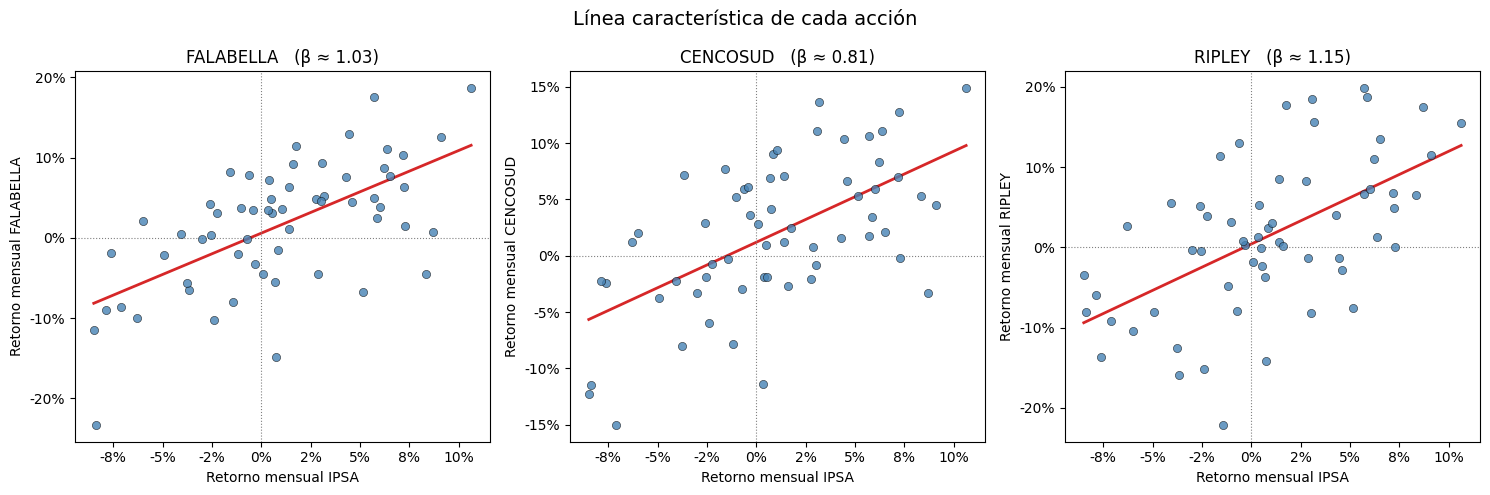

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, a in zip(axes, tick):
    b, a0 = np.polyfit(log_returns['IPSA'], log_returns[a], 1)
    x = np.linspace(log_returns['IPSA'].min(), log_returns['IPSA'].max(), 100)

    ax.scatter(log_returns['IPSA'], log_returns[a], s=35, color='steelblue',
               edgecolor='black', linewidth=0.4, alpha=0.8, zorder=3)
    ax.plot(x, a0 + b * x, color='#d62728', linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.xaxis.set_major_formatter(lambda v, _: f"{v*100:.0f}%")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v*100:.0f}%")
    ax.set_title(f"{a}   (β ≈ {b:.2f})")
    ax.set_xlabel("Retorno mensual IPSA")
    ax.set_ylabel(f"Retorno mensual {a}")

fig.suptitle("Línea característica de cada acción", fontsize=14)
plt.tight_layout()
plt.show()

---
## 🧮 Estimación del modelo de mercado

Estimaremos, para cada acción $i$, la regresión:

$$r_{i,t}=\alpha_{i}+\beta_{i}\,r_{M,t}+\varepsilon_{i,t}$$

mediante **mínimos cuadrados ordinarios (MCO)** con `statsmodels`. Como `statsmodels` no incluye el intercepto por defecto, debemos agregarlo explícitamente con `sm.add_constant()`.

### 🛍️ Un ejemplo detallado: Falabella

Comencemos con una sola acción para leer con calma la salida de la regresión.

In [32]:
X = sm.add_constant(log_returns['IPSA'])
modelo_falabella = sm.OLS(log_returns['FALABELLA'], X).fit()

print(modelo_falabella.summary())

                            OLS Regression Results                            
Dep. Variable:              FALABELLA   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     37.31
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           9.03e-08
Time:                        13:58:23   Log-Likelihood:                 82.965
No. Observations:                  60   AIC:                            -161.9
Df Residuals:                      58   BIC:                            -157.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0059      0.008      0.725      0.4

### 📖 ¿Cómo leer esta salida?

Las filas relevantes de la tabla central son:

* **`const`**: el intercepto $\hat{\alpha}$. Es el retorno mensual promedio de la acción que **no** se explica por el mercado. Bajo el CAPM debería ser cercano a cero.
* **`IPSA`**: la pendiente $\hat{\beta}$, es decir, el beta estimado.

Las columnas que acompañan a cada coeficiente son:

* **`std err`**: el error estándar de la estimación. Mide la **incertidumbre** del coeficiente.
* **`t`** y **`P>|t|`**: el estadístico $t=\hat{\beta}/\text{error estándar}$ y su valor-$p$, para contrastar si el coeficiente es distinto de cero.
* **`[0.025  0.975]`**: el intervalo de confianza al 95%.

Y, en el encabezado, el **`R-squared`** ($R^{2}$): la fracción de la varianza del retorno de la acción que es explicada por el mercado.

> ⚠️ Un beta estimado **no** es el beta verdadero: es una estimación con error. Fíjese en el ancho del intervalo de confianza antes de tomar decisiones con un beta "puntual".

In [33]:
beta_falabella = modelo_falabella.params['IPSA']
r2_falabella = modelo_falabella.rsquared

print(f"Si el IPSA sube 1% en un mes, FALABELLA tiende a subir {beta_falabella:.2f}% (en promedio).")
print(f"El mercado explica el {r2_falabella:.1%} de la varianza de los retornos mensuales de FALABELLA.")

Si el IPSA sube 1% en un mes, FALABELLA tiende a subir 1.03% (en promedio).
El mercado explica el 39.1% de la varianza de los retornos mensuales de FALABELLA.


### 🔁 Estimando las tres acciones

Ahora repetimos la estimación para las tres acciones. Guardamos los modelos en un diccionario, cuyas llaves son los símbolos, y armamos una **tabla resumen** con:

* el intercepto $\hat{\alpha}$;
* el beta $\hat{\beta}$, su error estándar, su estadístico $t$ y su intervalo de confianza al 95%;
* el $R^{2}$ y el número de observaciones.

In [34]:
modelos = {a: sm.OLS(log_returns[a], sm.add_constant(log_returns['IPSA'])).fit() for a in tick}

filas = []
for a, m in modelos.items():
    ci = m.conf_int().loc['IPSA']
    filas.append({
        'Acción': a,
        'Alfa': m.params['const'],
        'Beta': m.params['IPSA'],
        'Error estándar': m.bse['IPSA'],
        't (beta)': m.tvalues['IPSA'],
        'IC 95% inf.': ci.iloc[0],
        'IC 95% sup.': ci.iloc[1],
        'R²': m.rsquared,
        'Obs.': int(m.nobs),
    })

tabla_betas = pd.DataFrame(filas).set_index('Acción')
tabla_betas.style.format({'Alfa': '{:.4f}', 'Beta': '{:.3f}', 'Error estándar': '{:.3f}',
                          't (beta)': '{:.2f}', 'IC 95% inf.': '{:.3f}',
                          'IC 95% sup.': '{:.3f}', 'R²': '{:.3f}'})

,Alfa,Beta,Error estándar,t (beta),IC 95% inf.,IC 95% sup.,R²,Obs.
Acción,,,,,,,,
FALABELLA,0.0059,1.030,0.169,6.11,0.692,1.367,0.391,60
CENCOSUD,0.0119,0.808,0.145,5.56,0.517,1.098,0.348,60
RIPLEY,0.0042,1.155,0.216,5.35,0.723,1.587,0.331,60


In [35]:
# Si se desea guardar la tabla:
# tabla_betas.to_csv("Modelo_de_Mercado.csv", float_format="%.4f")

### ✅ Verificación: el beta como $\operatorname{Cov}/\operatorname{Var}$

Recordemos que el beta de MCO coincide con la covarianza entre la acción y el mercado dividida por la varianza del mercado. Verifiquemos esta igualdad con los datos:

In [36]:
beta_cov_var = log_returns[tick].apply(lambda s: s.cov(log_returns['IPSA'])) / log_returns['IPSA'].var()

comparacion = pd.DataFrame({'Beta (MCO)': tabla_betas['Beta'], 'Beta (Cov/Var)': beta_cov_var})
display(comparacion.style.format("{:.4f}"))
print("¿Coinciden?", np.allclose(comparacion['Beta (MCO)'], comparacion['Beta (Cov/Var)']))

,Beta (MCO),Beta (Cov/Var)
FALABELLA,1.0298,1.0298
CENCOSUD,0.8075,0.8075
RIPLEY,1.1548,1.1548


¿Coinciden? True


---
## 📊 Comparando los betas

Grafiquemos los betas estimados junto con su **intervalo de confianza al 95%**. La línea punteada marca $\beta=1$, el beta del mercado en su conjunto:

* $\beta>1$: acción **agresiva**, amplifica los movimientos del mercado.
* $\beta<1$: acción **defensiva**, los atenúa.

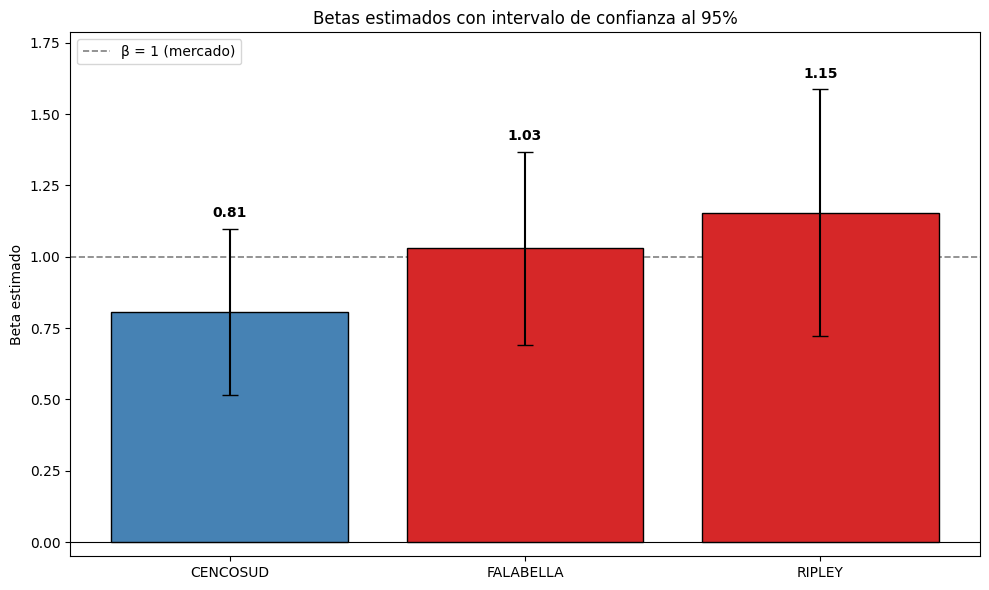

In [37]:
orden = tabla_betas.sort_values('Beta')
err_inf = orden['Beta'] - orden['IC 95% inf.']
err_sup = orden['IC 95% sup.'] - orden['Beta']
colores = ['#d62728' if b > 1 else 'steelblue' for b in orden['Beta']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(orden.index, orden['Beta'], yerr=[err_inf, err_sup], capsize=6,
       color=colores, edgecolor='black', zorder=3)
ax.axhline(1, color='gray', linestyle='--', linewidth=1.2, label='β = 1 (mercado)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(min(0, orden['IC 95% inf.'].min()) - 0.05, orden['IC 95% sup.'].max() + 0.2)

for i, (b, sup) in enumerate(zip(orden['Beta'], orden['IC 95% sup.'])):
    ax.text(i, sup + 0.03, f"{b:.2f}", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel("Beta estimado")
ax.set_title("Betas estimados con intervalo de confianza al 95%")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 🧩 Riesgo sistemático vs. riesgo específico

La regresión permite descomponer la varianza del retorno de cada acción en dos partes:

$$\operatorname{Var}\left(r_{i}\right)=\underbrace{\beta_{i}^{2}\operatorname{Var}\left(r_{M}\right)}_{\text{riesgo sistemático}}+\underbrace{\operatorname{Var}\left(\varepsilon_{i}\right)}_{\text{riesgo específico}}$$

Dividiendo por $\operatorname{Var}\left(r_{i}\right)$, la fracción sistemática es exactamente el $R^{2}$ de la regresión, y la fracción específica es $1-R^{2}$.

* El **riesgo sistemático** depende del mercado y **no se puede diversificar**; es el que el CAPM remunera.
* El **riesgo específico** es propio de la empresa y **sí se puede diversificar** al combinar varias acciones en un portafolio; por eso el mercado no lo remunera.

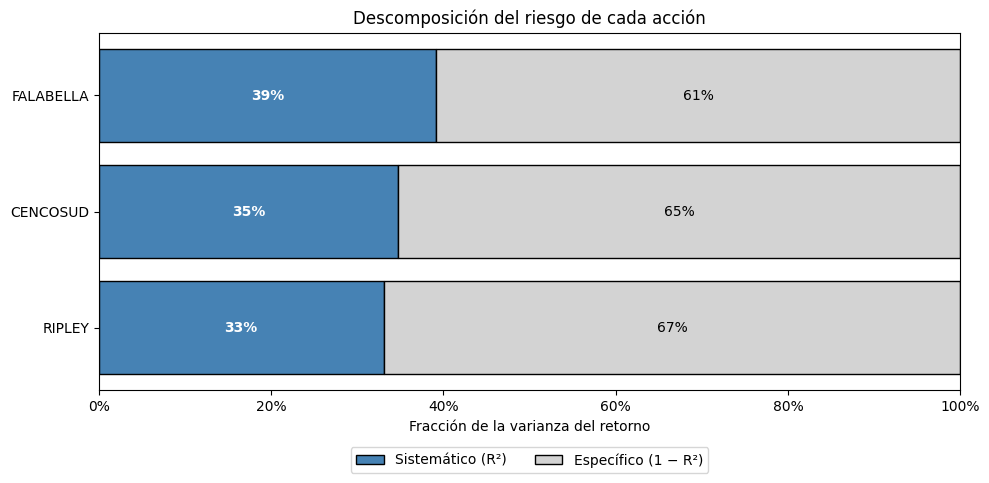

In [38]:
orden = tabla_betas.sort_values('R²')
sistematico = orden['R²']
especifico = 1 - orden['R²']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(orden.index, sistematico, color='steelblue', edgecolor='black', label='Sistemático (R²)')
ax.barh(orden.index, especifico, left=sistematico, color='lightgray', edgecolor='black',
        label='Específico (1 − R²)')

for i, (s, e) in enumerate(zip(sistematico, especifico)):
    ax.text(s / 2, i, f"{s:.0%}", ha='center', va='center', color='white', fontweight='bold')
    ax.text(s + e / 2, i, f"{e:.0%}", ha='center', va='center')

ax.xaxis.set_major_formatter(lambda v, _: f"{v*100:.0f}%")
ax.set_xlim(0, 1)
ax.set_xlabel("Fracción de la varianza del retorno")
ax.set_title("Descomposición del riesgo de cada acción")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.tight_layout()
plt.show()

---
## 🧭 Del beta al retorno esperado: el CAPM

Ahora usaremos los betas estimados para calcular el **retorno esperado** de cada acción según el CAPM:

$$E\left[r_{i}\right]=r_{f}+\beta_{i}\left(E\left[r_{M}\right]-r_{f}\right)$$

Necesitamos dos insumos adicionales:

* La tasa libre de riesgo $r_{f}$: usaremos la tasa que usted eligió de la Tabla 1 en la pregunta (c). **Debe ingresarla a mano** en la celda siguiente, en decimales (por ejemplo, 5,00% se escribe `0.05`). Esta misma tasa se usará más adelante para calcular el alfa de Jensen.
* La **prima de riesgo de mercado** $E\left[r_{M}\right]-r_{f}$. No la estimaremos con esta muestra, porque una prima calculada con cinco años de datos es extremadamente ruidosa. En su lugar, la fijamos como un **supuesto** que usted puede modificar.

> ⚠️ El valor de `prima_mercado` es un supuesto ilustrativo. Pruebe distintos valores y observe cómo cambia la pendiente de la SML y los retornos esperados.

In [39]:
# Tasa libre de riesgo: INGRÉSELA A MANO
# Use la misma tasa que eligió en la pregunta (c), en decimales (por ejemplo, 5,00% -> 0.05)
rf = 0.07   # <-- REEMPLACE 0.07 POR SU TASA

if rf is None:
    raise ValueError("Ingrese en `rf` la tasa libre de riesgo que eligió en la pregunta (c)")
print(f"Tasa libre de riesgo (elegida en la pregunta c): {rf * 100:.2f}%")

prima_mercado = 0.06   # SUPUESTO: prima de riesgo de mercado (6% anual)

capm = pd.DataFrame({'Beta': tabla_betas['Beta']})
capm['Retorno esperado (CAPM)'] = rf + capm['Beta'] * prima_mercado
capm.style.format({'Beta': '{:.3f}', 'Retorno esperado (CAPM)': '{:.2%}'})

Tasa libre de riesgo (elegida en la pregunta c): 7.00%


,Beta,Retorno esperado (CAPM)
Acción,,
FALABELLA,1.030,13.18%
CENCOSUD,0.808,11.85%
RIPLEY,1.155,13.93%


### 📈 La Línea de Mercado de Valores (SML)

Graficamos cada acción según su beta (eje horizontal) y su retorno esperado CAPM (eje vertical). Por construcción, todas quedan **sobre la recta**: la SML tiene intercepto $r_{f}$ y pendiente igual a la prima de riesgo de mercado.

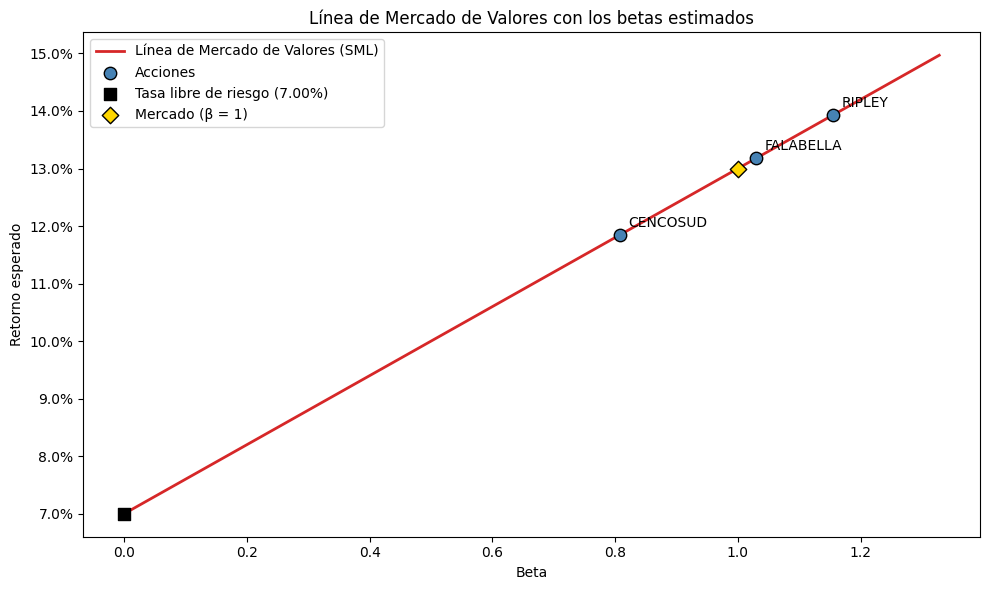

In [40]:
beta_grid = np.linspace(0, max(capm['Beta'].max(), 1) * 1.15, 100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(beta_grid, rf + prima_mercado * beta_grid, color='#d62728', linewidth=2,
        label='Línea de Mercado de Valores (SML)')
ax.scatter(capm['Beta'], capm['Retorno esperado (CAPM)'], s=80, color='steelblue',
           edgecolor='black', zorder=3, label='Acciones')

for a, fila in capm.iterrows():
    ax.annotate(a, (fila['Beta'], fila['Retorno esperado (CAPM)']),
                textcoords='offset points', xytext=(6, 6), fontsize=10)

ax.scatter([0], [rf], marker='s', s=70, color='black', zorder=3, label=f'Tasa libre de riesgo ({rf:.2%})')
ax.scatter([1], [rf + prima_mercado], marker='D', s=70, color='gold', edgecolor='black',
           zorder=3, label='Mercado (β = 1)')

ax.yaxis.set_major_formatter(lambda v, _: f"{v*100:.1f}%")
ax.set_xlabel("Beta")
ax.set_ylabel("Retorno esperado")
ax.set_title("Línea de Mercado de Valores con los betas estimados")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

---
## ⚠️ Precauciones metodológicas

Estimar un beta involucra decisiones que **cambian el resultado**. Antes de usar un beta en una valoración, tenga presente que:

* **El beta depende de la muestra.** Otra ventana de tiempo (por ejemplo, 2 años en vez de 5) o otra frecuencia (semanal o diaria en vez de mensual) entrega betas distintos.
* **El beta es una estimación con error.** Con 60 observaciones, los intervalos de confianza suelen ser amplios; dos acciones con betas puntuales distintos pueden ser estadísticamente indistinguibles.
* **El mercado es una aproximación.** El IPSA es solo un proxy de la cartera de mercado del CAPM, que en teoría incluye todos los activos riesgosos.
* **El beta cambia con el tiempo.** Cambios en el negocio, en el apalancamiento o en el ciclo económico modifican el riesgo sistemático de una empresa.
* **Retornos brutos vs. retornos en exceso.** Aquí regresamos retornos brutos, por simplicidad; la versión formal del CAPM utiliza retornos **en exceso** de la tasa libre de riesgo. Con datos mensuales, la diferencia en el beta suele ser pequeña, pero el intercepto cambia de significado: lo vemos en la última sección.
* **Ajuste de beta.** Es habitual "ajustar" los betas históricos hacia 1 (por ejemplo, $\beta_{aj}=\tfrac{2}{3}\hat{\beta}+\tfrac{1}{3}$), pues los betas tienden a acercarse a 1 con el tiempo.

### 🧭 Conclusión

El modelo de mercado permite estimar el beta de una acción como la pendiente de la regresión de sus retornos contra los del mercado, y entrega además su error estándar, un intervalo de confianza y el $R^{2}$, que separa el riesgo sistemático del específico.

Combinado con una tasa libre de riesgo y una prima de mercado, el beta permite calcular el retorno esperado de la acción con el CAPM, es decir, el **costo del capital propio** que exigen los inversionistas.

> 💡 En el notebook **Beta y Retorno Esperado** contrastamos, con las estimaciones de los grupos del curso, si los betas y los retornos esperados presentan la relación positiva que predice la SML.

---
# 🏆 Retornos en exceso y el alfa de Jensen

En las secciones anteriores estimamos el modelo de mercado con retornos **brutos**. Sin embargo, el CAPM no está escrito en términos de retornos, sino de **primas de riesgo**, es decir, de retornos **en exceso** de la tasa libre de riesgo:

$$E\left[r_{i}\right]-r_{f}=\beta_{i}\left(E\left[r_{M}\right]-r_{f}\right)$$

Para llevar esta ecuación a los datos, definimos el retorno en exceso de la acción y del mercado en cada mes $t$:

$$R_{i,t}=r_{i,t}-r_{f,t}\qquad\qquad R_{M,t}=r_{M,t}-r_{f,t}$$

y estimamos la regresión:

$$R_{i,t}=\alpha_{i}+\beta_{i}\,R_{M,t}+\varepsilon_{i,t}$$

### ❓ ¿Por qué la constante de esta regresión es el alfa de Jensen?

Tomemos esperanza a ambos lados de la regresión. Como $E\left[\varepsilon_{i,t}\right]=0$:

$$E\left[R_{i}\right]=\alpha_{i}+\beta_{i}\,E\left[R_{M}\right]$$

El CAPM, en cambio, afirma que $E\left[R_{i}\right]=\beta_{i}\,E\left[R_{M}\right]$: el retorno en exceso esperado depende **solo** del riesgo sistemático. Comparando ambas expresiones, la constante es exactamente la diferencia entre lo observado y lo que exige el CAPM:

$$\alpha_{i}=\underbrace{E\left[R_{i}\right]}_{\text{retorno en exceso observado}}-\underbrace{\beta_{i}\,E\left[R_{M}\right]}_{\text{retorno en exceso exigido por el CAPM}}$$

Esta medida se conoce como el **alfa de Jensen** (Jensen, 1968), y se interpreta como el **retorno anormal ajustado por riesgo**:

* $\alpha_{i}>0$: la acción rindió **más** de lo que compensa su riesgo sistemático (queda **sobre** la SML);
* $\alpha_{i}<0$: rindió **menos** de lo que compensa su riesgo sistemático (queda **bajo** la SML);
* $\alpha_{i}=0$: rindió exactamente lo que predice el CAPM.

Por eso, el test $t$ de la constante contrasta $H_{0}:\alpha_{i}=0$, es decir, si la acción es consistente con el CAPM. Bajo el CAPM, **todos** los alfas deberían ser cero.

### ⚠️ ¿Por qué esto no ocurre con retornos brutos?

Si en la regresión en exceso reemplazamos $R_{i,t}=r_{i,t}-r_{f,t}$ y $R_{M,t}=r_{M,t}-r_{f,t}$, y despejamos $r_{i,t}$:

$$r_{i,t}=\underbrace{\alpha_{i}+\left(1-\beta_{i}\right)r_{f}}_{\text{intercepto con retornos brutos}}+\beta_{i}\,r_{M,t}+\varepsilon_{i,t}$$

Con retornos brutos, el intercepto **mezcla** el alfa con un término, $\left(1-\beta_{i}\right)r_{f}$, que depende de la tasa libre de riesgo y del beta. Solo coincide con el alfa de Jensen si $\beta_{i}=1$ o si $r_{f}=0$. Además, aun si el CAPM fuera cierto, ese intercepto **no** sería cero, sino $\left(1-\beta_{i}\right)r_{f}$; por lo tanto, contrastar "intercepto $=0$" con retornos brutos sería el test equivocado.

> 💡 **Idea central:** con retornos en exceso, la constante mide la **distancia vertical entre la acción y la SML**. Con retornos brutos, en cambio, la constante no tiene esa interpretación.

### 📥 Tasa libre de riesgo mensual

Necesitamos una tasa libre de riesgo con **frecuencia mensual**, para restarla a los retornos mensuales. Usaremos la **misma tasa `rf` que usted ingresó a mano en la sección del CAPM** (la elegida en la pregunta c), de modo que todo el análisis use una única tasa libre de riesgo.

La tasa `rf` es anual y está en decimales. Para que sea comparable con nuestros retornos logarítmicos mensuales, la convertimos a un retorno logarítmico mensual:

$$r_{f}^{mensual}=\frac{\ln\left(1+r_{f}\right)}{12}$$

> ⚠️ Como usamos una única tasa, $r_{f}$ es **constante** en toda la muestra. Esto tiene una consecuencia que verificaremos más adelante: el beta con retornos en exceso es **idéntico** al beta con retornos brutos.

In [41]:
# Tasa libre de riesgo mensual: la misma tasa `rf` ingresada a mano en la sección del CAPM
if rf is None:
    raise ValueError("Ingrese en `rf` (sección del CAPM) la tasa libre de riesgo que eligió en la pregunta (c)")

# Tasa anual (decimal) -> retorno logarítmico mensual, constante para todos los meses
rf_mensual = pd.Series(np.log(1 + rf) / 12, index=log_returns.index)

print(f"Tasa libre de riesgo mensual: {rf_mensual.iloc[0]:.3%}  (≈ {rf:.2%} anual)")

Tasa libre de riesgo mensual: 0.564%  (≈ 7.00% anual)


### ➖ Retornos en exceso

Restamos la tasa libre de riesgo mensual a los retornos de cada acción **y** a los del mercado:

In [42]:
exceso = log_returns.sub(rf_mensual, axis=0)
exceso.head()

Ticker,FALABELLA,CENCOSUD,RIPLEY,IPSA
Date,,,,
2021-01,-0.050151,0.002393,-0.019306,0.023273
2021-02,0.170169,0.100153,0.060905,0.051422
2021-03,0.081484,0.077314,0.104390,0.056368
2021-04,-0.024769,-0.030018,-0.141710,-0.081933
2021-05,0.015113,0.014158,-0.110016,-0.065728


### 🔁 Estimando las tres acciones

Estimamos la regresión en exceso para cada acción. La tabla resumen destaca ahora el **intercepto**, que es el alfa de Jensen, junto con su error estándar, su estadístico $t$ y su valor-$p$. Como los retornos son mensuales, anualizamos el alfa multiplicándolo por 12.

Para leer con calma la salida completa, primero mostramos el modelo de Falabella: la fila `const` (Python) o `(Intercept)` (R) es el alfa de Jensen.

In [43]:
modelos_exc = {a: sm.OLS(exceso[a], sm.add_constant(exceso['IPSA'])).fit() for a in tick}

print(modelos_exc['FALABELLA'].summary())

                            OLS Regression Results                            
Dep. Variable:              FALABELLA   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     37.31
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           9.03e-08
Time:                        13:58:23   Log-Likelihood:                 82.965
No. Observations:                  60   AIC:                            -161.9
Df Residuals:                      58   BIC:                            -157.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0061      0.008      0.758      0.4

In [44]:
filas = []
for a, m in modelos_exc.items():
    ci = m.conf_int().loc['const']
    filas.append({
        'Acción': a,
        'Alfa mensual': m.params['const'],
        'Alfa anualizado': m.params['const'] * 12,
        'Error estándar (alfa)': m.bse['const'],
        't (alfa)': m.tvalues['const'],
        'Valor-p (alfa)': m.pvalues['const'],
        'IC 95% inf. (anual)': ci.iloc[0] * 12,
        'IC 95% sup. (anual)': ci.iloc[1] * 12,
        'Beta': m.params['IPSA'],
        'R²': m.rsquared,
    })

tabla_jensen = pd.DataFrame(filas).set_index('Acción')
tabla_jensen.style.format({'Alfa mensual': '{:.4f}', 'Alfa anualizado': '{:.2%}',
                           'Error estándar (alfa)': '{:.4f}', 't (alfa)': '{:.2f}',
                           'Valor-p (alfa)': '{:.3f}', 'IC 95% inf. (anual)': '{:.2%}',
                           'IC 95% sup. (anual)': '{:.2%}', 'Beta': '{:.3f}', 'R²': '{:.3f}'})

,Alfa mensual,Alfa anualizado,Error estándar (alfa),t (alfa),Valor-p (alfa),IC 95% inf. (anual),IC 95% sup. (anual),Beta,R²
Acción,,,,,,,,,
FALABELLA,0.0061,7.27%,0.0080,0.76,0.452,-11.94%,26.49%,1.030,0.391
CENCOSUD,0.0108,12.96%,0.0069,1.57,0.123,-3.60%,29.52%,0.808,0.348
RIPLEY,0.0051,6.09%,0.0102,0.50,0.622,-18.51%,30.69%,1.155,0.331


### 📖 ¿Cómo leer esta tabla?

* **Alfa mensual / anualizado:** el retorno anormal promedio de la acción, después de descontar el retorno que exige su riesgo sistemático.
* **$t$ y valor-$p$ del alfa:** contrastan $H_{0}:\alpha_{i}=0$. Un valor-$p$ menor que 0,05 (o $|t|$ mayor que aproximadamente 2) es evidencia de que el alfa es distinto de cero.
* **Beta:** la pendiente en exceso. Como $r_{f}$ es constante, es **idéntica** al beta estimado con retornos brutos.

> ⚠️ Con 60 observaciones mensuales, el error estándar del alfa suele ser **grande** en relación con el propio alfa: un alfa llamativo en la tabla no es, por sí solo, evidencia de retornos anormales. Fíjese siempre en el intervalo de confianza.
>
> Además, rechazar $H_{0}:\alpha_{i}=0$ no prueba que la acción "gane más que el mercado": es una **hipótesis conjunta**. El rechazo puede deberse a que el CAPM está mal especificado, o a que el IPSA es un mal proxy de la cartera de mercado.

### 🔍 Comparación con la regresión con retornos brutos

Verifiquemos la relación que dedujimos: el intercepto de la regresión con retornos brutos debería ser igual al alfa de Jensen más $\left(1-\beta_{i}\right)r_{f}$, donde $r_{f}$ es la tasa libre de riesgo mensual.

> 💡 Como usamos una tasa $r_{f}$ **constante**, la igualdad es **exacta** y los betas de ambas regresiones son idénticos. Si $r_{f}$ variara mes a mes (por ejemplo, con una serie de tasas de corto plazo), la igualdad sería solo aproximada.

In [45]:
rf_m = rf_mensual.iloc[0]   # tasa libre de riesgo mensual (constante)

comparacion_alfa = pd.DataFrame({
    'Intercepto (retornos brutos)': tabla_betas['Alfa'],
    'Alfa de Jensen (exceso)': tabla_jensen['Alfa mensual'],
    '(1 − β)·rf': (1 - tabla_jensen['Beta']) * rf_m,
})
comparacion_alfa['Alfa Jensen + (1 − β)·rf'] = (comparacion_alfa['Alfa de Jensen (exceso)']
                                                + comparacion_alfa['(1 − β)·rf'])
comparacion_alfa['Beta (brutos)'] = tabla_betas['Beta']
comparacion_alfa['Beta (exceso)'] = tabla_jensen['Beta']

comparacion_alfa.style.format("{:.4f}")

,Intercepto (retornos brutos),Alfa de Jensen (exceso),(1 − β)·rf,Alfa Jensen + (1 − β)·rf,Beta (brutos),Beta (exceso)
Acción,,,,,,
FALABELLA,0.0059,0.0061,-0.0002,0.0059,1.0298,1.0298
CENCOSUD,0.0119,0.0108,0.0011,0.0119,0.8075,0.8075
RIPLEY,0.0042,0.0051,-0.0009,0.0042,1.1548,1.1548


### 📊 Alfa de Jensen anualizado con intervalo de confianza

Graficamos los alfas anualizados junto con su intervalo de confianza al 95%. Si el intervalo **incluye el cero**, no podemos rechazar $H_{0}:\alpha_{i}=0$: el retorno de la acción es consistente con el CAPM.

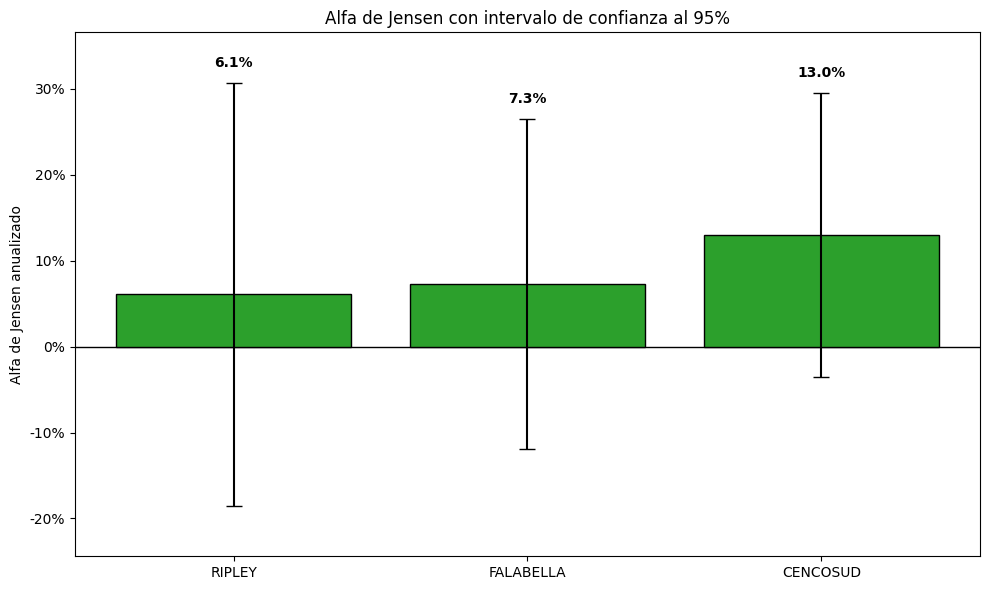

In [46]:
orden = tabla_jensen.sort_values('Alfa anualizado')
err_inf = orden['Alfa anualizado'] - orden['IC 95% inf. (anual)']
err_sup = orden['IC 95% sup. (anual)'] - orden['Alfa anualizado']
colores = ['#2ca02c' if a > 0 else '#d62728' for a in orden['Alfa anualizado']]
rango = orden['IC 95% sup. (anual)'].max() - orden['IC 95% inf. (anual)'].min()
margen = 0.03 * rango

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(orden.index, orden['Alfa anualizado'], yerr=[err_inf, err_sup], capsize=6,
       color=colores, edgecolor='black', zorder=3)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylim(min(orden['IC 95% inf. (anual)'].min(), 0) - 0.12 * rango,
            max(orden['IC 95% sup. (anual)'].max(), 0) + 0.12 * rango)

for i, (a, inf, sup) in enumerate(zip(orden['Alfa anualizado'], orden['IC 95% inf. (anual)'],
                                      orden['IC 95% sup. (anual)'])):
    if a >= 0:
        ax.text(i, sup + margen, f"{a:.1%}", ha='center', va='bottom', fontweight='bold')
    else:
        ax.text(i, inf - margen, f"{a:.1%}", ha='center', va='top', fontweight='bold')

ax.yaxis.set_major_formatter(lambda v, _: f"{v*100:.0f}%")
ax.set_ylabel("Alfa de Jensen anualizado")
ax.set_title("Alfa de Jensen con intervalo de confianza al 95%")
plt.tight_layout()
plt.show()

### 📈 El alfa de Jensen como distancia a la SML

Como la recta de mínimos cuadrados con intercepto pasa siempre por los promedios muestrales, el alfa estimado cumple exactamente:

$$\hat{\alpha}_{i}=\bar{R}_{i}-\hat{\beta}_{i}\,\bar{R}_{M}$$

Es decir, es la **distancia vertical** entre el retorno en exceso promedio de la acción y el punto que le correspondería sobre la **SML muestral**, una recta que parte en el origen y cuya pendiente es la prima de mercado observada en la muestra, $\bar{R}_{M}$.

Primero verificamos la igualdad y luego la graficamos. Las acciones **sobre** la recta tienen alfa positivo, y las que están **bajo** la recta, alfa negativo.

> ⚠️ Esta SML usa la prima de mercado **observada** en esta muestra (5 años), y no el supuesto de 6% de la sección del CAPM. Por eso, en este gráfico las acciones ya no quedan "sobre la recta por construcción": la distancia a la recta es justamente el alfa.

In [47]:
prima_muestral = exceso['IPSA'].mean() * 12      # prima de mercado observada (anualizada)
ret_medio = exceso[tick].mean() * 12              # retorno en exceso promedio de cada acción (anualizado)
betas_exc = tabla_jensen['Beta']

alfa_desde_medias = ret_medio - betas_exc * prima_muestral
print("¿Alfa de Jensen = retorno en exceso medio − β × prima de mercado observada?",
      np.allclose(alfa_desde_medias, tabla_jensen['Alfa anualizado']))

¿Alfa de Jensen = retorno en exceso medio − β × prima de mercado observada? True


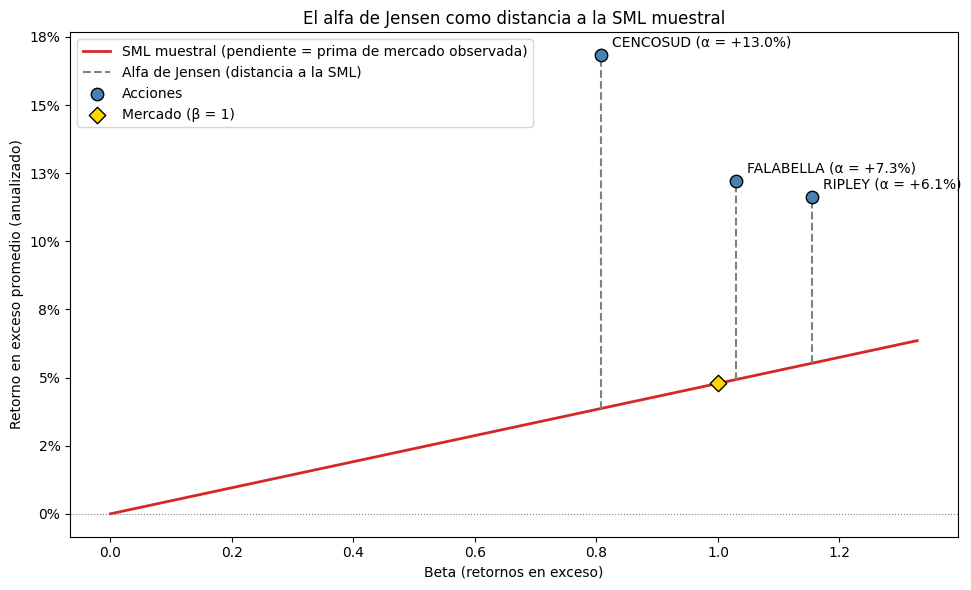

In [48]:
beta_grid = np.linspace(0, max(betas_exc.max(), 1) * 1.15, 100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(beta_grid, prima_muestral * beta_grid, color='#d62728', linewidth=2,
        label='SML muestral (pendiente = prima de mercado observada)')
ax.vlines(betas_exc, prima_muestral * betas_exc, ret_medio, color='gray', linestyle='--',
          linewidth=1.5, zorder=2, label='Alfa de Jensen (distancia a la SML)')
ax.scatter(betas_exc, ret_medio, s=80, color='steelblue', edgecolor='black', zorder=3, label='Acciones')
ax.scatter([1], [prima_muestral], marker='D', s=70, color='gold', edgecolor='black', zorder=3,
           label='Mercado (β = 1)')

for a in tick:
    ax.annotate(f"{a} (α = {tabla_jensen.loc[a, 'Alfa anualizado']:+.1%})",
                (betas_exc[a], ret_medio[a]), textcoords='offset points', xytext=(8, 6), fontsize=10)

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.yaxis.set_major_formatter(lambda v, _: f"{v*100:.0f}%")
ax.set_xlabel("Beta (retornos en exceso)")
ax.set_ylabel("Retorno en exceso promedio (anualizado)")
ax.set_title("El alfa de Jensen como distancia a la SML muestral")
ax.legend(loc='best')
plt.tight_layout()
plt.show()

### 🧭 Síntesis

* Con **retornos brutos**, la pendiente es el beta, pero el intercepto **no** tiene una interpretación económica clara: mezcla el alfa con $\left(1-\beta_{i}\right)r_{f}$.
* Con **retornos en exceso**, la pendiente sigue siendo el beta, y el intercepto es el **alfa de Jensen**: el retorno anormal ajustado por riesgo, o la distancia de la acción a la SML.
* El **beta** es el insumo para calcular el **costo del capital propio** con el CAPM. El **alfa**, en cambio, sirve para **evaluar el desempeño** de una acción o de un administrador de portafolios, una vez descontado el riesgo sistemático que asumió.
* Bajo el CAPM, el alfa esperado es cero. Con muestras pequeñas, los alfas estimados son ruidosos, y pocas veces son estadísticamente distintos de cero.